In [1]:
import numpy as np

arrA = np.array([9, 2, 3, 4])
result_loop = []

for i in arrA:
    result_loop.append(i * 10)

result_loop = np.array(result_loop)
print("Loop result:", result_loop)

Loop result: [90 20 30 40]


In [2]:
# Vectorized elementwise multiplication
result_vectorized = arrA * 10

print("Vectorized result:", result_vectorized)

Vectorized result: [90 20 30 40]


In [3]:
import pandas as pd

import pandas as pd

df = pd.read_csv("../data/raw/starter_data.csv")
import os
os.makedirs("../data/processed", exist_ok=True)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [4]:
df.describe()

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [5]:
category_summary = df.groupby("category")["value"].agg(["count", "mean", "std", "sum", "min", "max"])
print(category_summary)

          count       mean       std  sum  min  max
category                                           
A             4  11.500000  1.290994   46   10   13
B             3  15.666667  2.081666   47   14   18
C             3  27.666667  2.516611   83   25   30


In [6]:
import os
os.makedirs("../data/processed", exist_ok=True)

In [7]:
category_summary.to_csv("../data/processed/summary.csv")

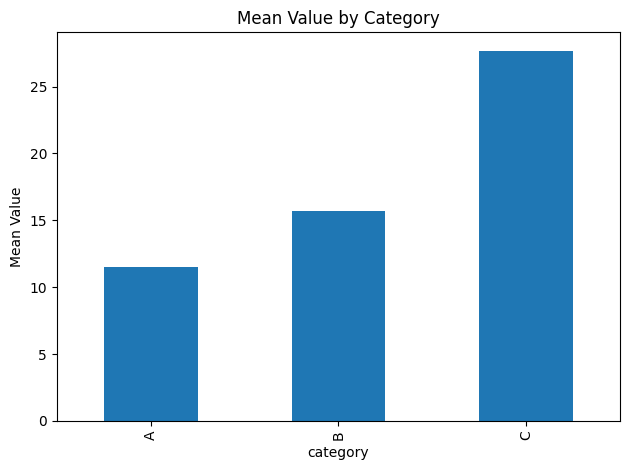

In [8]:
import matplotlib.pyplot as plt

category_summary["mean"].plot(kind="bar", title="Mean Value by Category")
plt.ylabel("Mean Value")
plt.tight_layout()
plt.savefig("../data/processed/category_means.png")
plt.show()

In [9]:
import pandas as pd

def get_summary_stats(df: pd.DataFrame, group_col: str = "category", target_col: str = "value") -> pd.DataFrame:
    """Compute aggregated statistics for a specified column grouped by category."""
    return df.groupby(group_col)[target_col].agg(["count", "mean", "std", "sum", "min", "max"])

In [10]:
import sys
sys.path.append("..")
from src.utils import get_summary_stats

stats_df = get_summary_stats(df, "category", "value")
stats_df

,count,mean,std,sum,min,max
category,,,,,,
A,4,11.500000,1.290994,46,10,13
B,3,15.666667,2.081666,47,14,18
C,3,27.666667,2.516611,83,25,30
